# AE for representation learning with `MNIST`

We now move to a concrete data problem and we will again use `MNIST`.

In this exercise, we will create a 4 layer AE (just like in the bellow figure). We will need to make the code from previous exercise more modular so that we can create multi-layer encoders/decoders.  

Let us remind that images in `MNIST` have shape $28 \times 28$. There are $50000$ images for training and $10000$ for test.

For this exercise we will prepare the data to be normalized in the interval $[-0.5, 0.5]$.

As we use MLP at each layer, we would like to flatten the input data from the very begining. Hence, we will add a Lamba torch.transform operations that flattens the usual gray image representation `[BATCH_SIZE,WIDTH,HEIGHT]` into `[BATCH_SIZE,CHANNEL_SIZE,WIDTH*HEIGHT]`

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt


#%%
#################################
#Some helpfull visualisation code#
#################################
def layout_images(images, n_rows=None, n_cols=None, border_size=2):
    height, width, n_channels = images[0].shape
    height, width = height + border_size, width + border_size
    if n_cols is None or n_rows is None:
        n_cols = int(np.sqrt(len(images)))
        if n_cols**2 < len(images):
            n_cols += 1
        n_rows = n_cols
    output_img = np.zeros((n_rows*height+border_size, n_cols*width+border_size, n_channels), dtype=images[0].dtype)
    for i, p in enumerate(images):
        r, c = i//n_cols, i%n_cols
        output_img[border_size+r*height:(r+1)*height, border_size+c*width:(c+1)*width] = p
    return output_img
    
#%%
################
#Dataset import#
################
data_preprocessing_transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize(0.5, 1),transforms.Lambda(lambda x: torch.flatten(x, start_dim=1))])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=data_preprocessing_transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=data_preprocessing_transform)

#Use a dummy dataloader to gain access to the entire dataset at once
#A dataloader is a generator, so we can associate an iterator iter() to it.
#Once the iterator is in place we ask for the first batch next() that returns the set of samples and the set of labels
x_train,y_train = next(iter(DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=False)))
x_test,y_test = next(iter(DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)))

##DataLoader did the work !
print("Unprocessed dataset shape :", train_dataset.data.shape)
print("Preprocessed dataset shape : ", x_train.shape)

#%% Constants
n = len(train_dataset)
d_inputs = 28 * 28
d_hidden1 = 100
d_hidden2 = 10  # codings
d_outputs = d_inputs
n_class = 10

Unprocessed dataset shape : torch.Size([60000, 28, 28])
Preprocessed dataset shape :  torch.Size([60000, 1, 784])


There are new elements in the code provided in the blocks below. In particular, an $L_2$ regularizer will be added to the `loss`. This additional loss term is embodied by function `reg`. The regularization applies to matrices ${\mathbf{W}^{(1)}}$ and ${\mathbf{W}^{(2)}}$ only.

### Q1

By taking inspiration from the previous exercise, fill the gaps in the constructor of the `AE` class:

- Observe that you must loop on layers for the **encoder** and loop a second time for the **decoder**.

- Fill the gaps in the `AE.__call__` function. Just like before this function maps $\mathbf{x}$ to $\mathbf{\tilde{x}}$. Again, we have one for the encoder followed by another loop for the decoder.

In [2]:
activation = torch.nn.ELU()

class AE(torch.nn.Module):
    def __init__(self, unit_nbrs, name=None):
        super(AE, self).__init__()
        self.K = len(unit_nbrs)-1
        self.params = nn.ParameterDict()
        for i in range(self.K):            
            self.params[f'w{i}']=nn.Parameter(torch.randn(unit_nbrs[i] , unit_nbrs[i+1]), requires_grad=True)
            self.params[f'b{i}']=nn.Parameter(torch.randn(unit_nbrs[i+1]), requires_grad=True)
        for i in range(self.K):        
            self.params[f'b{self.K+i}']=nn.Parameter(torch.randn(unit_nbrs[-i-2]),requires_grad=True)  
            
    def __call__(self, x):
        z = [x]
        for i in range(self.K):  
            z.append(activation(torch.matmul(z[-1], self.params[f'w{i}']) + self.params[f'b{i}']))
                     
        for i in range(self.K):
            z.append(activation(torch.matmul(z[-1], torch.transpose(self.params[f'w{self.K-1 -i}'],0,1)) + self.params[f'b{self.K+i}']))
        return z[-1]

    def coding(self,x):
        z = [x]
        for i in range(self.K):  
            z.append(activation(torch.matmul(z[-1], self.params[f'w{i}']) + self.params[f'b{i}']))
        return z[-1]
    
def loss(target,pred):
    return torch.mean((target - pred)**2) 

### Q3

You can instantiate an auto-encoder in the next cell and check if the maths work.

In [53]:
model = AE([ d_inputs , d_hidden1 , d_hidden2 ], name="my_AE")
x = x_train
model(x).shape

torch.Size([60000, 1, 784])

### Q4 

Fill the gaps in the `reg` function bellow. In this function, we need to loop on the trainable groups of parameters. In the code, we regrouped the trainable parameters under a `ParameterDict`. Using `key in model.params` we can iterate over the names of the model parameters. We filter them by checking the first letter of their name because intercepts are not to be included in the regularization.

<div style="background-color: #5CE65C; border:2px solid #ffb703; border-radius:8px; padding:10px; color:black;">

\begin{equation*}
L_2 \text{ regularization } = \text{loss } + \alpha \sum_{j=1}^p w_j^2
\end{equation*}

In [34]:
def reg(model,l2_reg):
    term = 0
    for key in model.params:
        if (key[0]=='w'):
            term += torch.sum(model.params[key] ** 2)
    return l2_reg*term

### Q5 

Proceed to the next cell where the training procedure starts by setting up hyper parameters and preparing the dataloader. Also, this time, we want to do mini-batch gradient descent. 
Use a DataLoader that allows us to process 10 images at a time.

In [54]:
model = AE([ d_inputs , d_hidden1 , d_hidden2 ], name="my_AE")

learning_rate = 1e-1
l2_reg = 1e-5
batch_size = 10
steps = n//batch_size

#%% Dataset loader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

#%% Optimizer and scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.96)
decay_step = 500 #do not forget to apply the lr update every 500 batches

#%% Training - loss of 0.05 after 5 epochs
train_loss_history=[]
test_loss_history=[]
train_mse_history = []
test_mse_history = []

n_epochs = 10

### Q6

Similarly as in the previous exercise, the missing instructions in the block bellow correspond to the main training phase.

What is specific here is that we need to add to the loss the regularization term before the backward pass. Pay attention to it !

In [58]:
for epoch in range(n_epochs):
    model.train()
    
    for step,(images,labels) in enumerate(train_loader):
        
        #reset gradients
        optimizer.zero_grad()
        
        #forward pass
        pred = model(images)
        #loss computation
        train_loss = loss(images, pred) + reg(model, l2_reg)
        
        #backward pass
        train_loss.backward()
        
        #parameters updated by the optimizer
        optimizer.step()

        #we then check if we need to reduce the learning rate
        if step > 0 and step % decay_step == 0:
            scheduler.step()
        
        print("\rEpoch %d - %d%% - \tf=%s" % (epoch, int(step/steps*100), train_loss.item()),end="\r")

    model.eval()

    train_loss_history.append((loss(x_train,model(x_train))+reg(model,l2_reg)).item())
    test_loss_history.append((loss(x_test,model(x_test))+reg(model,l2_reg)).item())
    
    train_mse_history.append((loss(x_train,model(x_train))).item())
    test_mse_history.append((loss(x_test,model(x_test))).item())

Epoch 9 - 99% - 	f=0.075506933033466345

### Q7

Plot the evolution of the aggregated loss w.r.t. to the time iterations.
Update the training loop so that you can dissociate on the plots the MSE loss from the regularization.

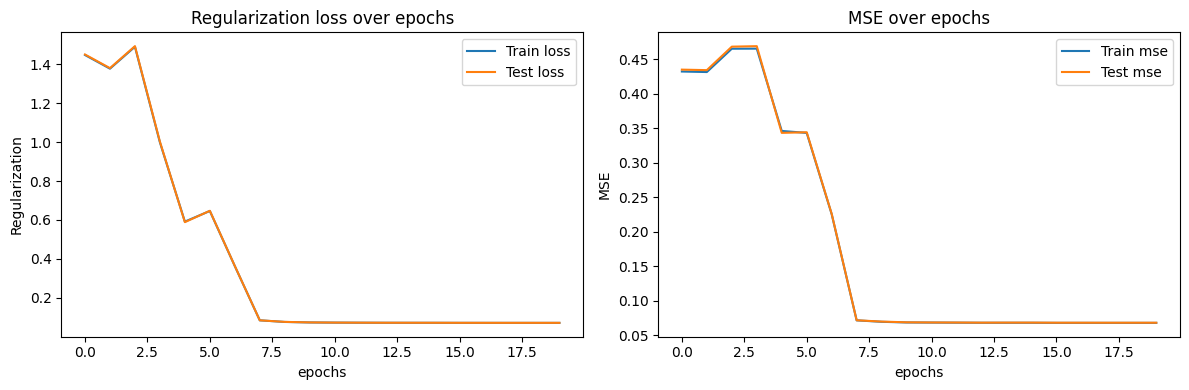

In [59]:
fig, axs = plt.subplots(1,2, figsize=(12,4))

axs[0].plot(train_loss_history, label='Train loss')
axs[0].plot(test_loss_history, label='Test loss')

axs[0].set_title('Regularization loss over epochs')
axs[0].set_xlabel("epochs")
axs[0].set_ylabel("Regularization")
axs[0].legend()

axs[1].plot(train_mse_history, label='Train mse')
axs[1].plot(test_mse_history, label='Test mse')
axs[1].set_title('MSE over epochs')
axs[1].set_xlabel("epochs")
axs[1].set_ylabel("MSE")
axs[1].legend()
plt.tight_layout()
plt.show()

### Q8

Proceed to the next cell and obtain reconstructed inputs from the *test set* and display pairs of images before/after reconstruction. 

The result should look like this :
<img src="im_reconst.png" width="300"> 

Adapt the code bellow in order to show two representatives of each class and their reconstruction. We shall for each class a line of 4 images (2 pairs of initial and reconstructed images). The `layout_images` functions should be called with the following parameters `layout_images(list of images, 10, 4)` (10 different numbers and 2x2 images for each number).

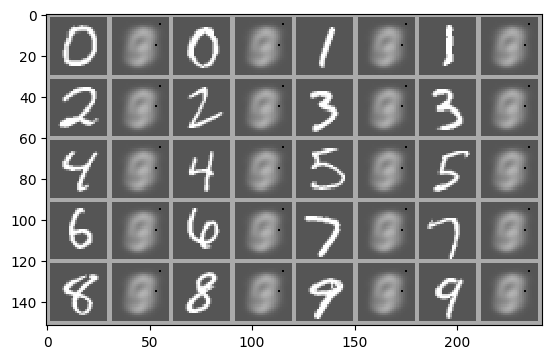

In [60]:
indice=1

imgs = []

with torch.no_grad():
    for i in range(0,10):
    
        x_tilde_1 = model(x_test[y_test==i][indice:indice+1]).detach().numpy()
        
        img1_1=x_test[y_test==i][indice:indice+1].detach().numpy().reshape(28,28,1).astype(np.float16)
        img1_2=np.reshape(x_tilde_1,(28,28,1)).astype(np.float16)
    
        imgs.append(img1_1)
        imgs.append(img1_2)
    
        x_tilde_2 = model(x_test[y_test==i][indice+1:indice+2]).detach().numpy()
        
        img2_1=x_test[y_test==i][indice+1:indice+2].detach().numpy().reshape(28,28,1).astype(np.float16)
        img2_2=np.reshape(x_tilde_2,(28,28,1)).astype(np.float16)
        
        imgs.append(img2_1)
        imgs.append(img2_2)

img=layout_images(imgs,5,8)

plt.imshow(img,cmap='gray', interpolation="nearest")

### Q9

Add a representation coding function to the model `model.coding(input)`(as in the previous excercise), so that we can obtain the representation of the samples in the hidden space. 

In [61]:
z_train = model.coding(x_train).squeeze(1).detach().numpy()
z_train.shape

(60000, 10)

### Q10

Compute the hidden representation for train samples of classes 0 to 4.
In order to facilitate the writing, you can compute the representation of the entire train set (`z_train=model.coding(x_train)`) and then you can make use of expression such as `x_train[y_train<4]` or `z_train[y_train<4]`.

### Q11

Construct a scatter plot of the representation using the first two coordinates of the representation `z_train[ .. ,0]` and `z_train[ .. ,1]`. In order to be able to differentiate between classes you can set the following parameter in the scatter command `c=y_train[ .. ]`, where the .. correspond to the filter you want to apply on the underlying data.

Construct a scatter plot prior to the training and another one post training.

Change the `reg_l2` parameter (5e-1, 5e-2, 5e-3, 5e-4) draw the scatter points and comment on the results obtained.

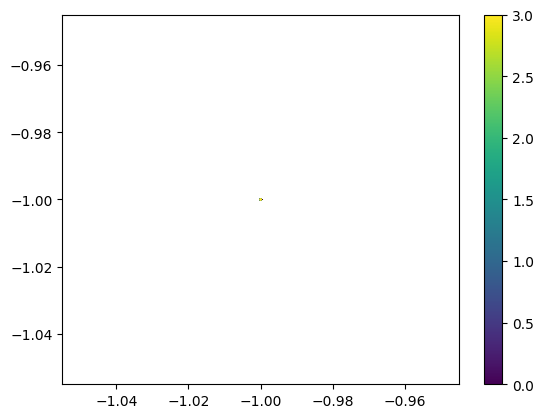

In [64]:
scatter = plt.scatter(z_train[y_train<4][:,0],z_train[y_train<4][:,1],c=y_train[y_train<4],s=1)
plt.colorbar(scatter)

### General comments and remarks

<div style="background-color: #5CE65C; border:2px solid #ffb703; border-radius:8px; padding:10px; color:black;">

I obtained an average image at the end maybe due to the encoder which is collapsed, indeed when we display the latent dimension, it results in a single point in the center. Then the encoder learned a constant and decoding a constant means that we will always obtain the same image with the reconstruction